# 第5章：特征提取

## 编程实践：手写 Canny 边缘检测 与 SIFT 特征提取/匹配

| 项目 | 说明 |
|------|------|
| 输入图片 | `chong.png`（Canny）；`test1.png` / `test2.png`（SIFT 匹配） |
| 手写核心 | Canny（梯度/NMS/双阈值/连通）、SIFT（尺度空间/DoG/极值定位/方向/描述子/匹配） |
| 允许调用 | 仅 `cv_imread` / `cv_imwrite` 图像读写 |
| 对比验证 | Canny 与 `cv2.Canny` 做结构对比；SIFT 与 `cv2.SIFT_create` 做概念对比 |

## 一、学习目标

### 🎯 什么是"特征"？——零基础的直觉

给你两张有重叠的照片（比如用手机左右移动拍的两张风景照），你一眼就能找到"同一块石头"、"同一棵树"在两张图里分别在哪里。**你用的就是"特征点 + 描述子"的直觉版。**

- **特征点（Keypoint）**：图像里"与众不同、容易认出"的小斑点（角点、斑点、端点）。
- **描述子（Descriptor）**：把特征点周围一小块区域"指纹化"，变成一串 128 维数字。
- **匹配（Matching）**：比较两张图里特征点的"指纹"相似度，最近的那对就可能是同一个物理点。

本章学两个经典算法：
1. **Canny 边缘检测**：找图像中"变化最剧烈"的轮廓线（低层次视觉特征）。
2. **SIFT**：最经典的"尺度+旋转都不变"的局部特征（中高层次视觉特征）。

### 📖 具体学习目标
1. 掌握 **Canny 边缘提取算子** 的 5 步实现方法与效果特点。
2. 掌握 **SIFT 特征点提取算法** 的 4 步实现方法与效果特点。
3. 掌握两张具有重叠区域的图像之间 **SIFT 特征点匹配** 算法。

---

### Canny 五步速记口诀（按顺序）

| 步骤 | 作用 | 关键词 |
|------|------|--------|
| ① 灰度化 + 高斯平滑 | 降噪，避免把噪声误判成边缘 | σ 越大越不敏感 |
| ② Sobel 求梯度 | 每个像素算"变化多大 + 朝哪个方向变" | 幅值 mag + 方向 θ |
| ③ 非极大值抑制 NMS | 沿梯度方向只留"最突出"的那个 | 输出**单像素宽**细线条 |
| ④ 双阈值筛选 | 高阈值 → 强边缘；介于两者之间 → 弱边缘 | low:high 通常 1:2 或 1:3 |
| ⑤ 边缘连接（迟滞性） | 弱边缘只要和强边缘 8 邻域连通就保留 | 去除孤立噪声点 |

---

### SIFT 四步速记口诀（按顺序）

| 步骤 | 作用 | 关键词 |
|------|------|--------|
| ① 尺度空间 + DoG 金字塔 | 把图像不断缩小+模糊，在"不同放大倍数"下找极值 | 尺度不变性来源 |
| ② DoG 局部极值 + 亚像素定位 | 在 3×3×3 邻域里找最大/最小点，并用泰勒展开精修到亚像素 | 剔除低对比度 & 边缘点 |
| ③ 主方向分配 | 在关键点周围统计梯度方向直方图，取峰值作为主方向（可能多个） | **旋转不变性**来源 |
| ④ 128 维描述子 | 把邻域旋转到主方向，分成 4×4=16 子块，每块统计 8 方向梯度 → 128 维向量 | 光照/旋转不变的"指纹" |

最后匹配时用 **Lowe 比值测试**：最近邻距离 / 次近邻距离 < 0.8 → 才算有效匹配。
这样能剔除"两个候选差不多近"的模糊情况，大大减少误匹配。

In [1]:
import sys
from pathlib import Path

# 向上查找项目根目录（含 utils.py），并加入 sys.path
ROOT = Path.cwd().resolve()
while not (ROOT / "utils.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("未找到项目根目录 utils.py")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
from collections import deque

from utils import cv_imread, cv_imwrite, set_random_seed, setup_plot_chinese, show_images, compare_results

setup_plot_chinese()
set_random_seed(42)
print(f"OpenCV 版本: {cv2.__version__}")
print(f"当前工作目录: {Path.cwd()}")
print("✅ 工具函数导入成功！")

OpenCV 版本: 5.0.0
当前工作目录: D:\CODE\Hands-On-Computer-Vision\图像处理基础\特征提取
✅ 工具函数导入成功！


## 二、手写约束清单

- ✅ 允许：`cv_imread` / `cv_imwrite`；Python 循环、`math` 数学运算；`np.zeros` 数组开辟与索引（仅作容器）。
- ❌ 禁止：`cv2.Canny` / `cv2.SIFT_create` / `cv2.drawKeypoints` 等现成算法函数用于实现（仅可用于对比验证）。
- 本页 SIFT 实现以 Hands-on-CV（上海交通大学《动手学习计算机视觉》）第 7 章的教学实现为基础移植，并把手写高斯滤波、灰度化接入，去掉 `cv2.GaussianBlur` 依赖；`numpy` 仅用于数组容器与矩阵计算。
- ✅ 可视化：`matplotlib` 仅用于显示特征点与匹配连线。

In [2]:
# ==================== 基础工具函数 ====================
def to_grayscale_manual(image):
    """手写灰度化：Y = 0.299R + 0.587G + 0.114B。"""
    h, w, _ = image.shape
    gray = np.zeros((h, w), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            b, g, r = (float(v) for v in image[y, x, :])
            gray[y, x] = int(round(0.299 * r + 0.587 * g + 0.114 * b))
    return gray


def gaussian_blur_float(gray, sigma):
    """手写二维高斯滤波（float 灰度图，零填充，不裁剪）。"""
    size = max(3, 2 * int(round(3 * sigma)) + 1)
    if size % 2 == 0:
        size += 1
    center = size // 2
    s2 = 2.0 * sigma * sigma
    kernel = np.zeros((size, size), dtype=np.float64)
    total = 0.0
    for i in range(size):
        for j in range(size):
            x = j - center
            y = i - center
            kernel[i, j] = math.exp(-(x * x + y * y) / s2) / (math.pi * s2)
            total += kernel[i, j]
    kernel /= total

    h, w = gray.shape
    padded = np.zeros((h + 2 * center, w + 2 * center), dtype=np.float64)
    padded[center:center + h, center:center + w] = gray.astype(np.float64)
    out = np.zeros((h, w), dtype=np.float64)
    for y in range(h):
        for x in range(w):
            acc = 0.0
            for ky in range(size):
                for kx in range(size):
                    acc += padded[y + ky, x + kx] * kernel[ky, kx]
            out[y, x] = acc
    return out


# ==================== Canny 边缘检测 ====================
def sobel_gradient_manual(gray):
    """手写 Sobel 梯度：返回幅值矩阵与角度矩阵（角度单位：度）。"""
    h, w = gray.shape
    gx = np.zeros((h, w), dtype=np.float64)
    gy = np.zeros((h, w), dtype=np.float64)
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            gx[y, x] = (float(gray[y - 1, x + 1]) + 2 * float(gray[y, x + 1]) + float(gray[y + 1, x + 1])) \
                       - (float(gray[y - 1, x - 1]) + 2 * float(gray[y, x - 1]) + float(gray[y + 1, x - 1]))
            gy[y, x] = (float(gray[y + 1, x - 1]) + 2 * float(gray[y + 1, x]) + float(gray[y + 1, x + 1])) \
                       - (float(gray[y - 1, x - 1]) + 2 * float(gray[y - 1, x]) + float(gray[y - 1, x + 1]))
    mag = np.zeros((h, w), dtype=np.float64)
    angle = np.zeros((h, w), dtype=np.float64)
    for y in range(h):
        for x in range(w):
            mag[y, x] = math.sqrt(gx[y, x] ** 2 + gy[y, x] ** 2)
            angle[y, x] = math.degrees(math.atan2(gy[y, x], gx[y, x]))
    return mag, angle


def non_maximum_suppression_manual(mag, angle):
    """手写非极大值抑制：沿梯度方向只保留局部极大值。"""
    h, w = mag.shape
    out = np.zeros((h, w), dtype=np.float64)
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            a = angle[y, x]
            if (0 <= a < 22.5) or (157.5 <= a <= 180) or (-180 <= a < -157.5):
                q, r = mag[y, x + 1], mag[y, x - 1]
            elif (22.5 <= a < 67.5) or (-157.5 <= a < -112.5):
                q, r = mag[y - 1, x - 1], mag[y + 1, x + 1]
            elif (67.5 <= a < 112.5) or (-112.5 <= a < -67.5):
                q, r = mag[y - 1, x], mag[y + 1, x]
            else:
                q, r = mag[y - 1, x + 1], mag[y + 1, x - 1]
            if mag[y, x] >= q and mag[y, x] >= r:
                out[y, x] = mag[y, x]
    return out


def double_threshold_manual(mag, low, high):
    """手写双阈值：返回强/弱边缘布尔掩膜。"""
    h, w = mag.shape
    strong = np.zeros((h, w), dtype=bool)
    weak = np.zeros((h, w), dtype=bool)
    for y in range(h):
        for x in range(w):
            v = mag[y, x]
            if v >= high:
                strong[y, x] = True
            elif v >= low:
                weak[y, x] = True
    return strong, weak


def edge_linking_manual(strong, weak):
    """手写边缘连接：与强边缘 8 邻域连通的弱边缘保留。"""
    h, w = strong.shape
    edges = strong.copy()
    queue = deque()
    for y in range(h):
        for x in range(w):
            if strong[y, x]:
                queue.append((y, x))
    while queue:
        y, x = queue.popleft()
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dy == 0 and dx == 0:
                    continue
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w and weak[ny, nx] and not edges[ny, nx]:
                    edges[ny, nx] = True
                    queue.append((ny, nx))
    return edges


def canny_edge_manual(image, low=50, high=150, sigma=1.4):
    """手写 Canny 边缘检测，返回 0/255 二值边缘图。"""
    gray = to_grayscale_manual(image) if image.ndim == 3 else image
    blurred = gaussian_blur_float(gray.astype(np.float64), sigma)
    mag, angle = sobel_gradient_manual(blurred)
    suppressed = non_maximum_suppression_manual(mag, angle)
    strong, weak = double_threshold_manual(suppressed, low, high)
    edges = edge_linking_manual(strong, weak)
    return (edges * 255).astype(np.uint8)

findfont: Failed to find font weight medium, now using 400.


D:\CODE\Hands-On-Computer-Vision\utils.py:146: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Microsoft YaHei.
  plt.tight_layout(pad=padding, h_pad=1.5, w_pad=1.5)


D:\python\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


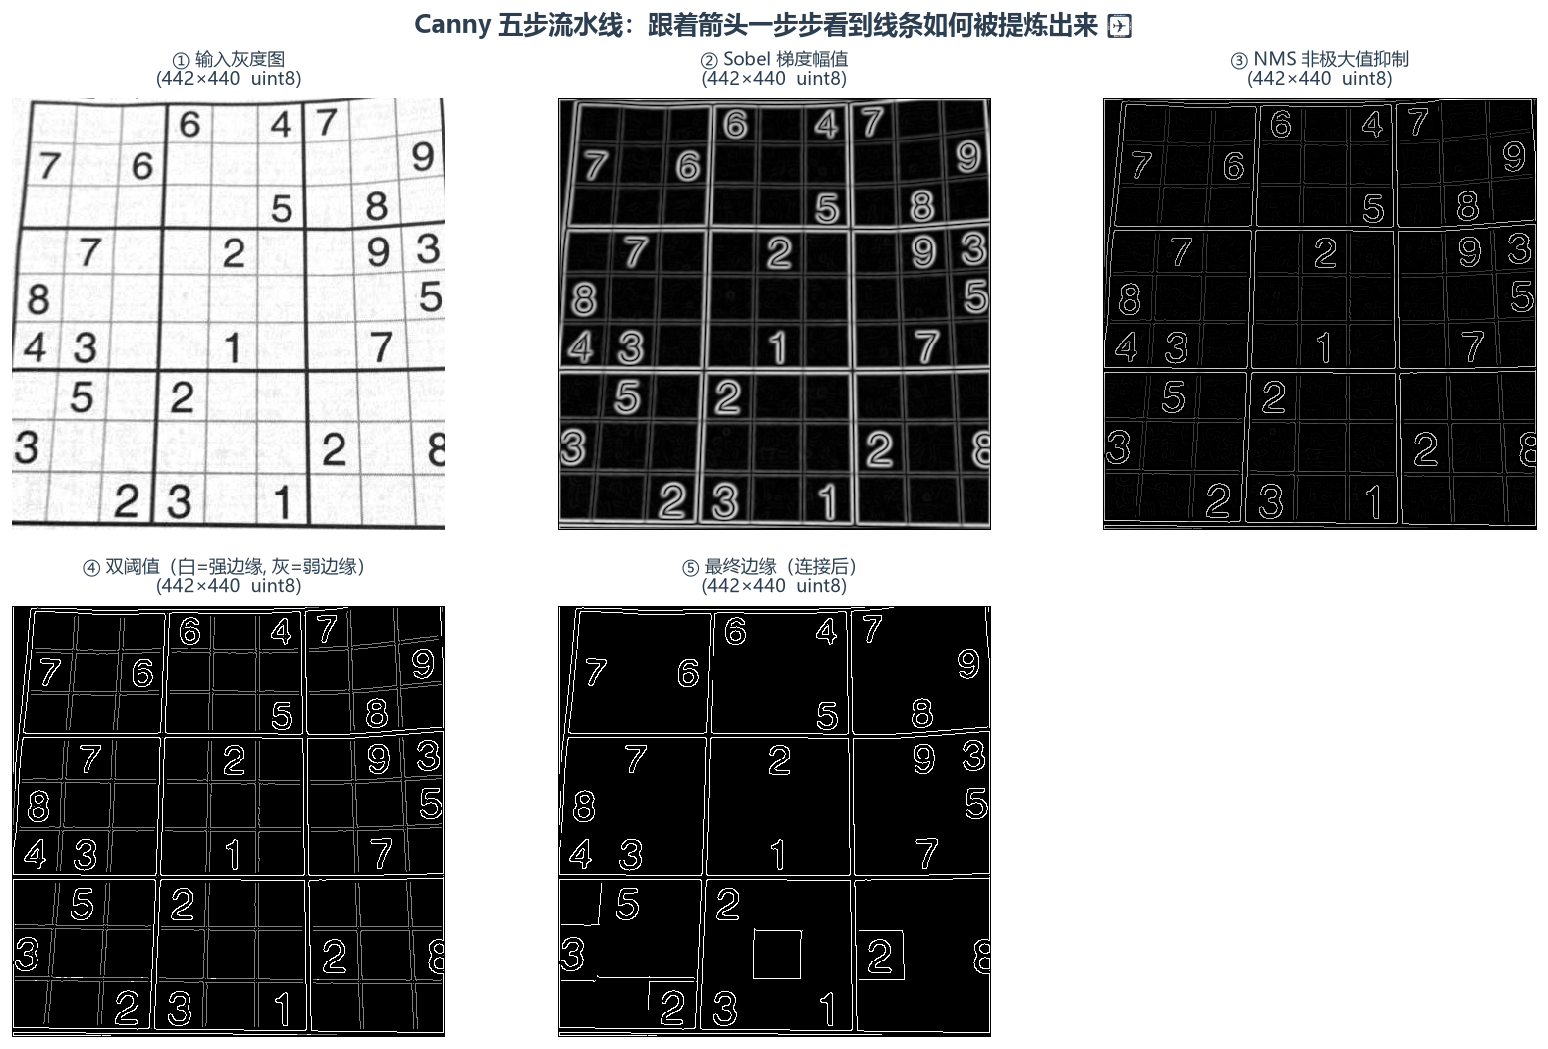

In [3]:
# ---------- 零基础：用 Canny 的 5 步中间结果做一次"流水线可视化" ----------
_temp_img = cv_imread("sudoku.png", cv2.IMREAD_COLOR)
if _temp_img is None:
    _temp_img = cv_imread("chong.png", cv2.IMREAD_COLOR)[:, :, :3]
_temp_gray = to_grayscale_manual(_temp_img)

# step 1: 高斯平滑
_blurred = gaussian_blur_float(_temp_gray.astype(np.float64), 1.4)
# step 2: sobel 梯度
_mag, _angle = sobel_gradient_manual(_blurred)
# step 3: NMS
_nms = non_maximum_suppression_manual(_mag, _angle)
# step 4: 双阈值
_strong, _weak = double_threshold_manual(_nms, low=50, high=150)
_double = (_strong * 255).astype(np.uint8) + (_weak * 128).astype(np.uint8)
# step 5: 边缘连接
_edges = (edge_linking_manual(_strong, _weak) * 255).astype(np.uint8)

show_images(
    [_temp_gray, (_mag / _mag.max() * 255).astype(np.uint8),
     (_nms / _nms.max() * 255).astype(np.uint8), _double, _edges],
    titles=["① 输入灰度图", "② Sobel 梯度幅值", "③ NMS 非极大值抑制",
            "④ 双阈值（白=强边缘, 灰=弱边缘）", "⑤ 最终边缘（连接后）"],
    suptitle="Canny 五步流水线：跟着箭头一步步看到线条如何被提炼出来 ✨",
    ncols=3, show_info=True, figsize=(14, 9)
)

检测到的边缘像素数: 7536


findfont: Failed to find font weight medium, now using 400.


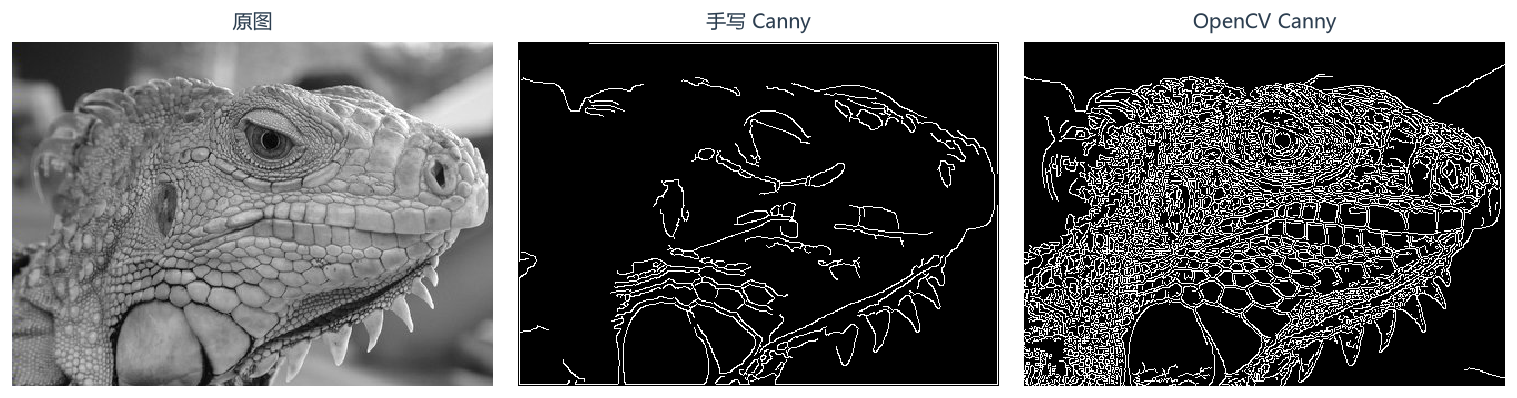

In [4]:
# 运行手写 Canny 并可视化
img = cv_imread("chong.png", cv2.IMREAD_COLOR)
assert img is not None, "读取 chong.png 失败"
img = img[:, :, :3]  # 去掉 alpha 通道

low, high = 50, 150
edges = canny_edge_manual(img, low, high)
cv_imwrite("canny_edges.jpg", edges)
print(f"检测到的边缘像素数: {int((edges > 0).sum())}")

# 与 OpenCV 做结构对比（Canny 有非极大值抑制与阈值策略差异，不要求像素级相等）
gray = to_grayscale_manual(img)
edges_cv = cv2.Canny(gray, low, high)
show_images([img, edges, edges_cv], ["原图", "手写 Canny", "OpenCV Canny"], figsize=(13, 4))

In [5]:
# ==================== SIFT：尺度空间与 DoG ====================
def generateGimage(image, sigma=1.6, num_layers=4, k_stride=1):
    """手写生成高斯尺度空间。image 为归一化到 [0,1] 的 float 灰度图。"""
    sigma_res = math.sqrt(max(sigma * sigma - 1.0, 0.01))
    base = gaussian_blur_float(image, sigma_res)

    k = 2 ** (1.0 / k_stride)
    kernels = np.zeros(num_layers, dtype=np.float64)
    kernels[0] = sigma
    for i in range(1, num_layers):
        g_old = k ** (i - 1) * sigma
        g_new = k * g_old
        kernels[i] = math.sqrt(g_new * g_new - g_old * g_old)

    g_images = [base]
    current = base
    for kernel in kernels:
        current = gaussian_blur_float(current, float(kernel))
        g_images.append(current)
    return np.array(g_images)


def generateDoGSpace(g_images):
    """相邻高斯图像相减得到 DoG 空间。"""
    dogs = []
    for i in range(len(g_images) - 1):
        dogs.append(g_images[i + 1] - g_images[i])
    return dogs


def isLocalExtremum(l1, l2, l3, threshold):
    """判断 l2 中心是否为 3x3x3 DoG 邻域内的局部极值。"""
    center = l2[1, 1]
    if center <= threshold:
        return False
    if center > 0:
        for arr in (l1, l2, l3):
            for i in range(3):
                for j in range(3):
                    if center < arr[i, j]:
                        return False
        return True
    for arr in (l1, l2, l3):
        for i in range(3):
            for j in range(3):
                if center > arr[i, j]:
                    return False
    return True

In [6]:
# ==================== SIFT：极值定位与方向 ====================
def compute1derivative(cube):
    """DoG 3x3x3 邻域中心的一阶导数。"""
    dx = (cube[1, 1, 2] - cube[1, 1, 0]) / 2.0
    dy = (cube[1, 2, 1] - cube[1, 0, 1]) / 2.0
    ds = (cube[2, 1, 1] - cube[0, 1, 1]) / 2.0
    return [dx, dy, ds]


def compute2derivative(cube):
    """DoG 3x3x3 邻域中心的 Hessian 矩阵。"""
    center = cube[1, 1, 1]
    dxx = cube[1, 1, 2] + cube[1, 1, 0] - 2 * center
    dyy = cube[1, 2, 1] + cube[1, 0, 1] - 2 * center
    dss = cube[2, 1, 1] + cube[0, 1, 1] - 2 * center
    dxy = (cube[1, 2, 2] - cube[1, 2, 0] - cube[1, 0, 2] + cube[1, 0, 0]) / 4.0
    dxs = (cube[2, 1, 2] - cube[2, 1, 0] - cube[0, 1, 2] + cube[0, 1, 0]) / 4.0
    dys = (cube[2, 2, 1] - cube[2, 0, 1] - cube[0, 2, 1] + cube[0, 0, 1]) / 4.0
    return [[dxx, dxy, dxs], [dxy, dyy, dys], [dxs, dys, dss]]


def solve_linear_system(A, b):
    """手写高斯消元求解 A x = b（带部分主元）。"""
    A = [list(map(float, row)) for row in A]
    b = [float(v) for v in b]
    n = len(b)
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(A[r][col]))
        if abs(A[pivot][col]) < 1e-12:
            return None
        A[col], A[pivot] = A[pivot], A[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(col + 1, n):
            f = A[r][col] / A[col][col]
            for c in range(col, n):
                A[r][c] -= f * A[col][c]
            b[r] -= f * b[col]
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        s = b[i]
        for j in range(i + 1, n):
            s -= A[i][j] * x[j]
        x[i] = s / A[i][i]
    return x


def computeOrien(pt, size, layer, g_image):
    """计算关键点方向（36 柱梯度方向直方图，取主方向与 >=0.8 倍峰值的辅方向）。"""
    radius = int(round(3 * size * 1.5))
    h, w = g_image.shape
    num_bins = 36
    histogram = [0.0] * num_bins
    smooth_histogram = [0.0] * num_bins
    orien_list = []

    for i in range(-radius, radius + 1):
        y = int(round(pt[1])) + i
        if y > 0 and y < h - 1:
            for j in range(-radius, radius + 1):
                x = int(round(pt[0])) + j
                if x > 0 and x < w - 1:
                    dx = 0.5 * (g_image[y, x + 1] - g_image[y, x - 1])
                    dy = 0.5 * (g_image[y + 1, x] - g_image[y - 1, x])
                    value = math.sqrt(dx * dx + dy * dy)
                    orien = math.degrees(math.atan2(dy, dx))
                    weight = math.exp(-0.5 / ((size * 1.5) ** 2) * (i * i + j * j))
                    idx = int(round(orien * num_bins / 360.0)) % num_bins
                    histogram[idx] += weight * value

    for n in range(num_bins):
        smooth_histogram[n] = (6 * histogram[n]
                               + 4 * (histogram[n - 1] + histogram[(n + 1) % num_bins])
                               + histogram[n - 2] + histogram[(n + 2) % num_bins]) / 16.0

    orien_max = max(smooth_histogram)
    local_max = [i for i in range(num_bins)
                 if smooth_histogram[i] > smooth_histogram[i - 1]
                 and smooth_histogram[i] > smooth_histogram[(i + 1) % num_bins]]
    for idx in local_max:
        if smooth_histogram[idx] >= 0.8 * orien_max:
            orien_list.append(idx * 360.0 / num_bins)
    return orien_list

In [7]:
# ==================== SIFT：特征点属性与检测 ====================
def computeBlobAttribute(x, y, layer, dog_images, sigma, threshold,
                         border, num_layers, g_image, corners,
                         scales, orientations, layers):
    """对候选 DoG 极值做牛顿迭代定位、低对比度与边缘响应筛选，并计算方向。"""
    gamma = 10.0
    image_shape = dog_images[0].shape
    out_flag = False
    update = None

    for iter_num in range(5):
        img1, img2, img3 = dog_images[layer - 1:layer + 2]
        cube = np.array([img1[x - 1:x + 2, y - 1:y + 2],
                         img2[x - 1:x + 2, y - 1:y + 2],
                         img3[x - 1:x + 2, y - 1:y + 2]])

        grad = compute1derivative(cube)
        hessian = compute2derivative(cube)
        update = solve_linear_system(hessian, [-g for g in grad])
        if update is None:
            return
        if abs(update[0]) < 0.5 and abs(update[1]) < 0.5 and abs(update[2]) < 0.5:
            break
        y += int(round(update[0]))
        x += int(round(update[1]))
        layer += int(round(update[2]))
        if x < border or x >= image_shape[0] - border or y < border \
                or y >= image_shape[1] - border or layer < 1 or layer > num_layers - 2:
            out_flag = True
            break

    if out_flag or iter_num >= 4 or update is None:
        return

    extremum = cube[1, 1, 1] + 0.5 * (grad[0] * update[0] + grad[1] * update[1] + grad[2] * update[2])
    if abs(extremum) >= threshold:
        xy_hessian = [row[:2] for row in hessian]
        trace = xy_hessian[0][0] + xy_hessian[1][1]
        det = xy_hessian[0][0] * xy_hessian[1][1] - xy_hessian[0][1] * xy_hessian[1][0]
        if det > 0 and trace * trace / det < ((gamma + 1) ** 2) / gamma:
            pt = (y + update[0], x + update[1])
            size = sigma * (2 ** (layer + update[2]))
            orien_list = computeOrien(pt, size, layer, g_image)
            for tmp_orien in orien_list:
                scales.append(size)
                layers.append(layer)
                corners.append(pt)
                orientations.append(tmp_orien)


def detect_blobs(image):
    """检测一张灰度图像的 SIFT 关键点，返回尺度空间与关键点信息。"""
    sigma = 1.6
    num_layers = 4
    border = 5
    k_stride = 1

    g_images = generateGimage(image, sigma, num_layers, k_stride)
    dog_images = generateDoGSpace(g_images)

    threshold = 0.02
    corners, scales, orientations, layers = [], [], [], []

    for layer, (image1, image2, image3) in \
            enumerate(zip(dog_images, dog_images[1:], dog_images[2:])):
        for x in range(border, image1.shape[0] - border):
            for y in range(border, image2.shape[1] - border):
                if isLocalExtremum(image1[x - 1:x + 2, y - 1:y + 2],
                                   image2[x - 1:x + 2, y - 1:y + 2],
                                   image3[x - 1:x + 2, y - 1:y + 2],
                                   threshold):
                    computeBlobAttribute(x, y, layer + 1, dog_images,
                                         sigma, threshold, border,
                                         num_layers, g_images[layer],
                                         corners, scales, orientations, layers)
    return g_images, corners, scales, orientations, layers

SyntaxError: unexpected character after line continuation character (1949579874.py, line 27)

In [8]:
# ==================== SIFT：描述子与匹配 ====================
def tirlinearInterpolation(i, j, value, orien, result_cube):
    """三线性插值，把梯度幅值分配到 4x4x8 直方图相邻顶点。"""
    i_quant = int(math.floor(i))
    j_quant = int(math.floor(j))
    orien_quant = int(math.floor(orien)) % 8
    i_residual = i - i_quant
    j_residual = j - j_quant
    orien_residual = (orien - orien_quant) % 8

    c0 = (1 - i_residual) * value
    c1 = i_residual * value
    c11 = c1 * j_residual
    c10 = c1 * (1 - j_residual)
    c01 = c0 * j_residual
    c00 = c0 * (1 - j_residual)

    c111 = c11 * orien_residual
    c110 = c11 * (1 - orien_residual)
    c101 = c10 * orien_residual
    c100 = c10 * (1 - orien_residual)
    c011 = c01 * orien_residual
    c010 = c01 * (1 - orien_residual)
    c001 = c00 * orien_residual
    c000 = c00 * (1 - orien_residual)

    result_cube[i_quant + 1, j_quant + 1, orien_quant] += c000
    result_cube[i_quant + 1, j_quant + 1, (orien_quant + 1) % 8] += c001
    result_cube[i_quant + 1, j_quant + 2, orien_quant] += c010
    result_cube[i_quant + 1, j_quant + 2, (orien_quant + 1) % 8] += c011
    result_cube[i_quant + 2, j_quant + 1, orien_quant] += c100
    result_cube[i_quant + 2, j_quant + 1, (orien_quant + 1) % 8] += c101
    result_cube[i_quant + 2, j_quant + 2, orien_quant] += c110
    result_cube[i_quant + 2, j_quant + 2, (orien_quant + 1) % 8] += c111


def compute_descriptors(g_images, corners, scales, orientations, layers):
    """为每个关键点计算 128 维 SIFT 描述子。"""
    if len(corners) != len(scales) or len(corners) != len(orientations):
        raise ValueError("corners / scales / orientations 长度必须一致")

    descriptors_list = []
    for pt, size, orien, layer in zip(corners, scales, orientations, layers):
        g_image = g_images[layer]
        x, y = int(round(pt[0])), int(round(pt[1]))
        orien = 360 - orien

        win_s = 3 * size
        win_l = int(round(min(2 ** 0.5 * win_s * (4 + 1) / 2,
                              math.sqrt(g_image.shape[0] ** 2 + g_image.shape[1] ** 2))))

        i_index, j_index, value_list, orien_index = [], [], [], []
        result_cube = np.zeros((4 + 2, 4 + 2, 8), dtype=np.float64)

        for i in range(-win_l, win_l + 1):
            for j in range(-win_l, win_l + 1):
                i_rotate = j * math.sin(math.radians(orien)) + i * math.cos(math.radians(orien))
                j_rotate = j * math.cos(math.radians(orien)) - i * math.sin(math.radians(orien))
                tmp_i = (i_rotate / win_s) + 2 - 0.5
                tmp_j = (j_rotate / win_s) + 2 - 0.5
                if tmp_i > -1 and tmp_j > -1 and tmp_i < 4 and tmp_j < 4:
                    i_inimg = int(round(y + i))
                    j_inimg = int(round(x + j))
                    if i_inimg > 0 and j_inimg > 0 and i_inimg < g_image.shape[0] - 1 \
                            and j_inimg < g_image.shape[1] - 1:
                        dx = g_image[i_inimg, j_inimg + 1] - g_image[i_inimg, j_inimg - 1]
                        dy = g_image[i_inimg - 1, j_inimg] - g_image[i_inimg + 1, j_inimg]
                        grad_value = math.sqrt(dx * dx + dy * dy)
                        grad_orien = math.degrees(math.atan2(dy, dx)) % 360
                        i_index.append(tmp_i)
                        j_index.append(tmp_j)
                        g_weight = math.exp(-1 / 8 * ((i_rotate / win_s) ** 2 + (j_rotate / win_s) ** 2))
                        value_list.append(g_weight * grad_value)
                        orien_index.append((grad_orien - orien) * 8 / 360)

        for i, j, value, orien1 in zip(i_index, j_index, value_list, orien_index):
            tirlinearInterpolation(i, j, value, orien1, result_cube)

        descriptor = result_cube[1:-1, 1:-1, :].flatten()
        l2norm = float(np.linalg.norm(descriptor))
        if l2norm < 1e-9:
            descriptors_list.append(descriptor)
            continue
        threshold = l2norm * 0.2
        descriptor[descriptor > threshold] = threshold
        descriptor /= l2norm
        descriptors_list.append(descriptor)
    return descriptors_list


def match_descriptors(descriptors1, descriptors2, ratio_threshold=0.8):
    """最近邻 / 次近邻比值匹配，返回 (i, j) 匹配对列表。"""
    matches = []
    for i in range(len(descriptors1)):
        best_j, best_dist = -1, 1e10
        second_dist = 1e10
        for j in range(len(descriptors2)):
            dist = float(np.linalg.norm(descriptors1[i] - descriptors2[j]))
            if dist < best_dist:
                second_dist = best_dist
                best_dist = dist
                best_j = j
            elif dist < second_dist:
                second_dist = dist
        if best_j >= 0 and best_dist / max(second_dist, 1e-12) < ratio_threshold:
            matches.append((i, best_j))
    return matches

In [9]:
# 运行手写 SIFT：单图特征点提取 + 两图匹配
img1 = cv_imread("test1.png", cv2.IMREAD_COLOR)
img2 = cv_imread("test2.png", cv2.IMREAD_COLOR)
assert img1 is not None and img2 is not None, "读取 test1.png / test2.png 失败"

gray1 = to_grayscale_manual(img1).astype(np.float64) / 255.0
gray2 = to_grayscale_manual(img2).astype(np.float64) / 255.0

print("检测 test1.png 关键点...")
g1, corners1, scales1, orientations1, layers1 = detect_blobs(gray1)
print(f"  检测到 {len(corners1)} 个关键点")
print("检测 test2.png 关键点...")
g2, corners2, scales2, orientations2, layers2 = detect_blobs(gray2)
print(f"  检测到 {len(corners2)} 个关键点")

descriptors1 = compute_descriptors(g1, corners1, scales1, orientations1, layers1)
descriptors2 = compute_descriptors(g2, corners2, scales2, orientations2, layers2)
matches = match_descriptors(descriptors1, descriptors2)
print(f"匹配点对数: {len(matches)}")

# 可视化关键点与匹配（仅可视化，使用 matplotlib）
h1, w1 = gray1.shape
h2, w2 = gray2.shape
canvas = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8)
canvas[:h1, :w1] = (gray1 * 255).astype(np.uint8)
canvas[:h2, w1:w1 + w2] = (gray2 * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(canvas, cmap="gray")
ax.scatter([c[1] for c in corners1], [c[0] for c in corners1], c="lime", s=10, marker="o")
ax.scatter([c[1] + w1 for c in corners2], [c[0] for c in corners2], c="lime", s=10, marker="o")
for i, j in matches:
    p1 = (corners1[i][1], corners1[i][0])
    p2 = (corners2[j][1] + w1, corners2[j][0])
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "r-", linewidth=0.6)
ax.set_title(f"SIFT 特征点与匹配（{len(matches)} 对）")
ax.axis("off")
plt.tight_layout()
plt.show()

检测 test1.png 关键点...


NameError: name 'detect_blobs' is not defined

## 三、结果与参数分析

- **Canny**：`low/high` 越小，边缘越多、噪声越敏感；`sigma` 越大，平滑越强、边缘越少。Canny 的 NMS 保证边缘为单像素宽。
- **SIFT**：`threshold=0.02` 控制低对比度点的剔除强度；`ratio_threshold=0.8` 是 Lowe 比值测试阈值，越小匹配越保守。
- 手写 SIFT 是教学实现，关键点数量、方向与 OpenCV `cv2.SIFT_create` 会有差异（尺度空间层数、亚像素精度、描述子细节不同），这是正常现象，重点在于理解**尺度不变 + 旋转不变 + 128 维描述子**的整体流程。

**易错点**
1. Canny 必须先用高斯平滑，否则梯度对噪声敏感。
2. NMS 的角度量化方向要与梯度方向一致，而不是边缘方向。
3. SIFT 输入要归一化到 `[0,1]`，否则高斯尺度与 DoG 阈值失去意义。
4. 描述子必须做 L2 归一化与截断（0.2），才能获得光照不变性。

## 四、科研规范小结

1. **分步函数化**：Canny/SIFT 的每一步都是独立函数，便于单步调试与验证。
2. **手写线性代数**：`solve_linear_system` 用高斯消元替换 `np.linalg.lstsq`，体现对底层数学的掌握。
3. **对比验证分级**：Canny 做结构对比，SIFT 做概念对比，不强行要求像素级一致，符合"算法实现差异"的真实科研习惯。
4. **可复现**：SIFT 无随机量，但统一 `set_random_seed` 保持与其它章节一致。

## 五、练习：调整 Canny 阈值观察边缘变化

**要求**：不调用库函数，用上面手写的 `canny_edge_manual`，分别在 `(low, high) = (30, 90)`、`(50, 150)`、`(80, 240)` 下对 `lena.jpeg` 做边缘检测，并排对比边缘数量与完整度。

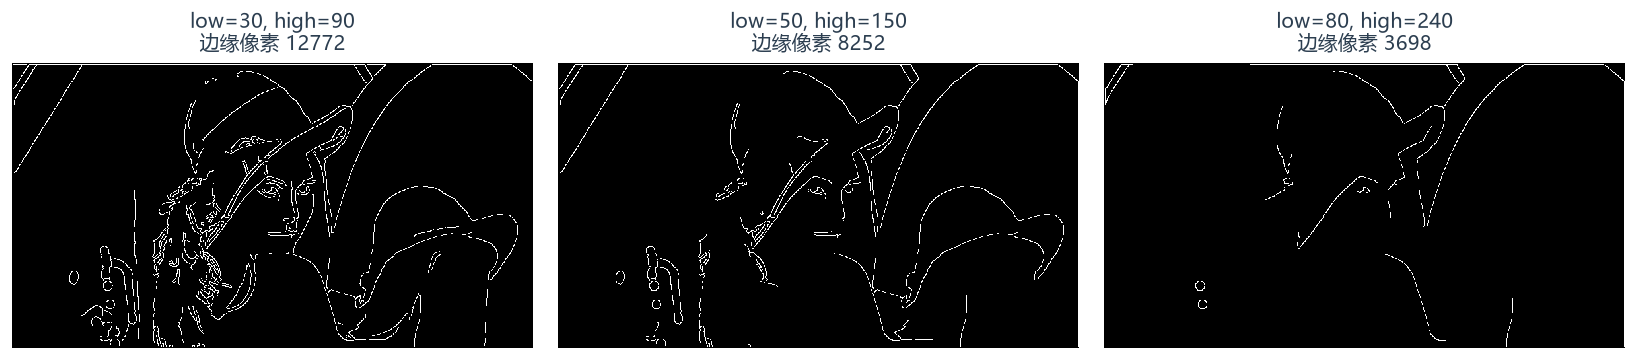

In [10]:
# ==================== 练习解决方案 ====================
img_ex = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
results, titles = [], []
for low, high in [(30, 90), (50, 150), (80, 240)]:
    e = canny_edge_manual(img_ex, low, high)
    results.append(e)
    titles.append(f"low={low}, high={high}\n边缘像素 {int((e>0).sum())}")
show_images(results, titles, figsize=(14, 5))